## makeover monday 2026-02-02

### big mac index

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('https://query.data.world/s/qpxaloahayolrcmmenwngpafk3tgzt?dws=00000')
df.tail(2)

,date,iso_a3,currency_code,name,local_price,dollar_ex,dollar_price,USD_raw,EUR_raw,GBP_raw,JPY_raw,CNY_raw,GDP_bigmac,adj_price,USD_adjusted,EUR_adjusted,GBP_adjusted,JPY_adjusted,CNY_adjusted
1892,1/1/2025,VNM,VND,Vietnam,76000.0,25078.0000,3.030545,-0.47659,-0.49092,-0.47072,-0.02546,-0.13863,7764.116477,4.184349,-0.32854,-0.42345,-0.38562,0.15727,-0.09800
1893,1/1/2025,ZAF,ZAR,South Africa,51.9,18.6913,2.776693,-0.52043,-0.53356,-0.51505,-0.10709,-0.21078,12583.467910,4.260454,-0.39577,-0.48119,-0.44714,0.04139,-0.18832


C:\Users\vivek\AppData\Local\Temp\ipykernel_3560\1127708745.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='USD_adjusted', y='name', data=top_diff, palette='coolwarm', ax=axs[0,0])
C:\Users\vivek\AppData\Local\Temp\ipykernel_3560\1127708745.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='USD_adjusted', y='name', data=top10, palette='viridis', ax=axs[0,1])
C:\Users\vivek\AppData\Local\Temp\ipykernel_3560\1127708745.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='USD_adjusted', y='name', data=top10, palette='pastel', ax

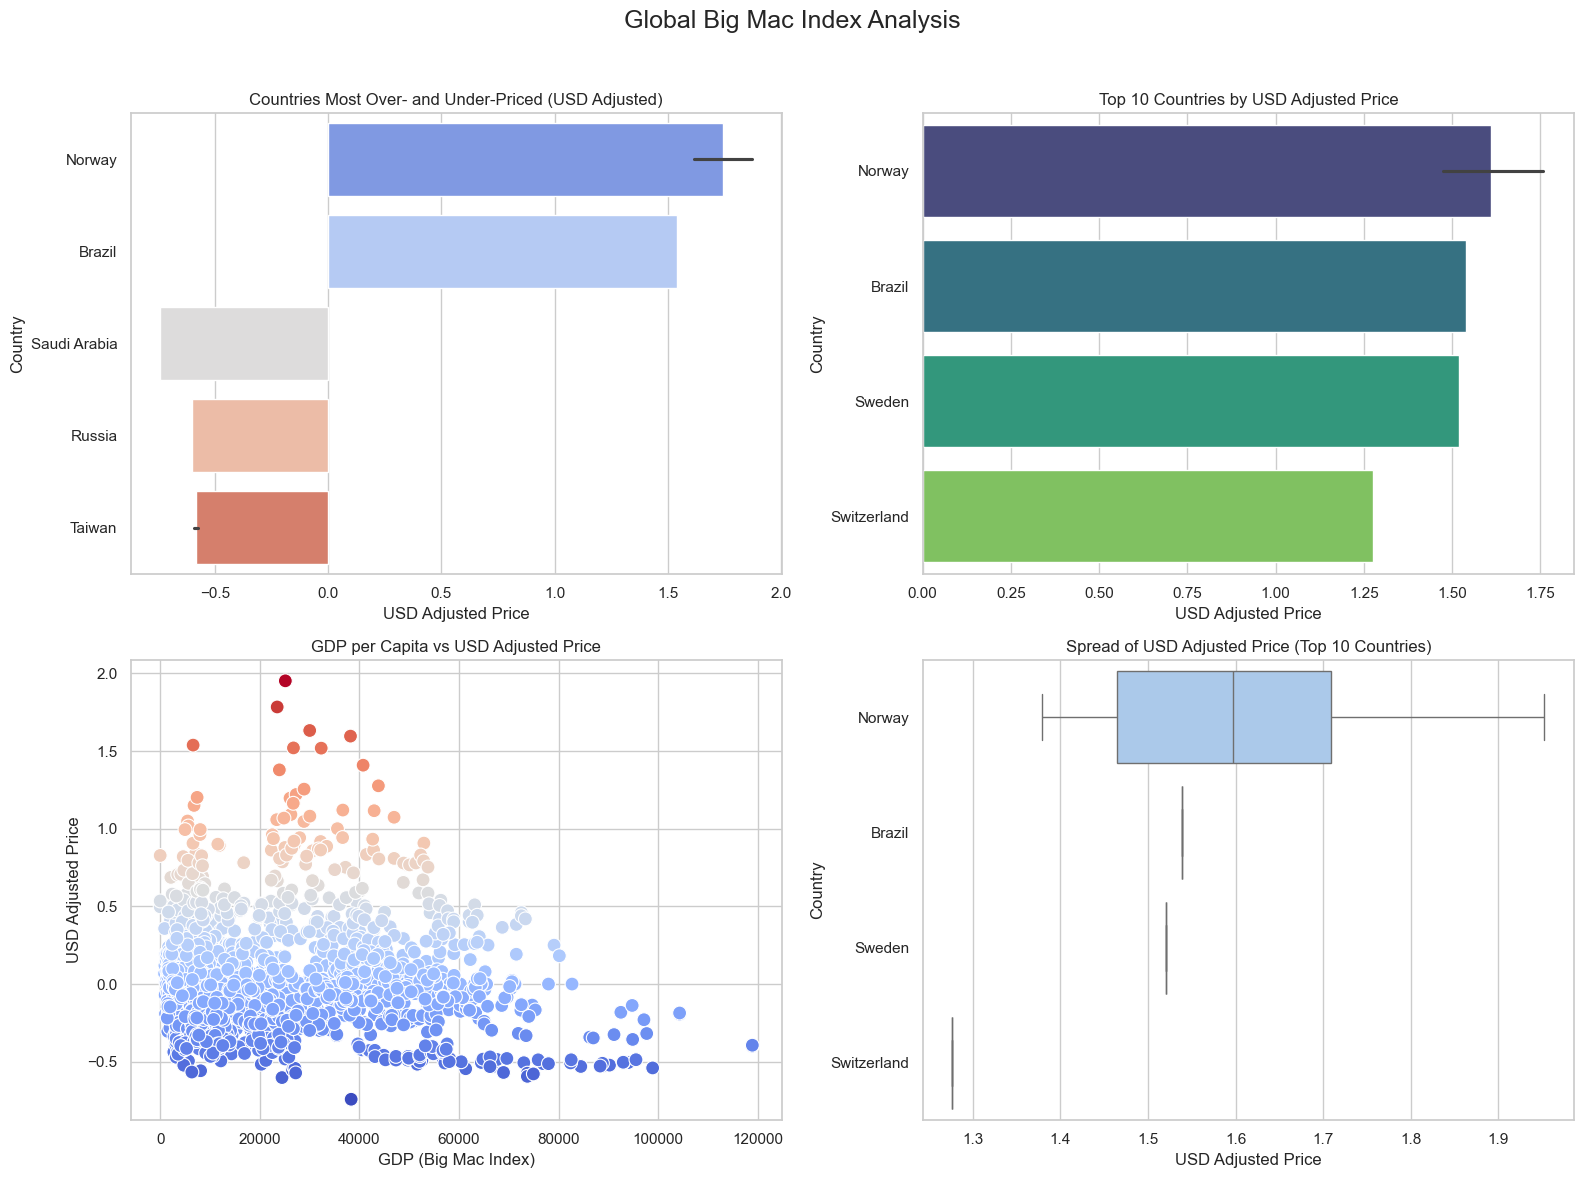

In [6]:
# Top 10 over- and under-priced countries
top_over = df.nlargest(5, 'USD_adjusted')
top_under = df.nsmallest(5, 'USD_adjusted')
top_diff = pd.concat([top_over, top_under])

sns.set(style="whitegrid")
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Global Big Mac Index Analysis", fontsize=18)

# 1. Top/Bottom USD Adjusted Price (replaces histogram)
sns.barplot(x='USD_adjusted', y='name', data=top_diff, palette='coolwarm', ax=axs[0,0])
axs[0,0].set_title("Countries Most Over- and Under-Priced (USD Adjusted)")
axs[0,0].set_xlabel("USD Adjusted Price")
axs[0,0].set_ylabel("Country")

# 2. Bar chart of USD_adjusted (top 10 countries)
top10 = df.nlargest(10, 'USD_adjusted')
sns.barplot(x='USD_adjusted', y='name', data=top10, palette='viridis', ax=axs[0,1])
axs[0,1].set_title("Top 10 Countries by USD Adjusted Price")
axs[0,1].set_xlabel("USD Adjusted Price")
axs[0,1].set_ylabel("Country")

# 3. Scatter plot of GDP_bigmac vs USD_adjusted
sns.scatterplot(x='GDP_bigmac', y='USD_adjusted', data=df, hue='USD_adjusted', palette='coolwarm', ax=axs[1,0], legend=False, s=100)
axs[1,0].set_title("GDP per Capita vs USD Adjusted Price")
axs[1,0].set_xlabel("GDP (Big Mac Index)")
axs[1,0].set_ylabel("USD Adjusted Price")

# 4. Boxplot of USD_adjusted (top 10 countries)
sns.boxplot(x='USD_adjusted', y='name', data=top10, palette='pastel', ax=axs[1,1])
axs[1,1].set_title("Spread of USD Adjusted Price (Top 10 Countries)")
axs[1,1].set_xlabel("USD Adjusted Price")
axs[1,1].set_ylabel("Country")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()